# 02. Risk Score Modeling v2

본 노트북은 격자 단위 교통사고 위험지표를 산출하기 위한 two-stage risk modeling을 수행한다.

모델 구조는 다음과 같다.

1. Logistic Regression  
   - 목표: 사고 발생 여부(`acc_binary`) 예측
   - 산출값: `risk_prob`

2. Negative Binomial Regression  
   - 목표: 격자별 사고건수(`acc_cnt`)의 기대값 예측
   - 산출값: `risk_intensity`

3. Final Risk Score  
   - 정의: `risk_score = risk_prob × risk_intensity`

이때 `risk_intensity`는 "사고 발생 시 강도"가 아니라,  
격자 단위에서의 **기대 사고건수(expected accident count)** 로 해석한다.

In [5]:
# 필요한 라이브러리 설정

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_absolute_error
)

from shapely import wkt
from shapely.geometry.base import BaseGeometry

sns.set_theme(style="whitegrid", palette="deep", context="notebook", font_scale=1.1)
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (8, 5)

DATA_DIR = "../outputs/processed"
RAW_DIR = "../dataset"

print("DATA_DIR:", DATA_DIR)
print("RAW_DIR:", RAW_DIR)

DATA_DIR: ../outputs/processed
RAW_DIR: ../dataset


In [6]:
## 이미 만들어진 base feature 불러오기

train_base = pd.read_csv(os.path.join(DATA_DIR, "02_train_base_with_facilities.csv"))
pred_base = pd.read_csv(os.path.join(DATA_DIR, "02_pred_base_core_features_gyosan.csv"))

print("train_base:", train_base.shape)
print("pred_base:", pred_base.shape)

display(train_base.head(2))
display(pred_base.head(2))

train_base: (105032, 21)
pred_base: (1302, 4)


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,다사581304,경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,다사581305,경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,gid,city,geometry,resident_pop
0,다사720443,경기도 하남시,POLYGON ((127.18323318250009 37.49753532003152...,47.607266
1,다사720443,경기도 하남시,POLYGON ((127.18323318250009 37.49753532003152...,0.000000


In [7]:
# 토지이용 원본 로드

grid4_block = gpd.read_file(os.path.join(RAW_DIR, "22._토지이용계획도_(4개_신도시).geojson"))
gridg_block = gpd.read_file(os.path.join(RAW_DIR, "23._토지이용계획도_(하남교산).geojson"))

print("grid4_block:", grid4_block.shape)
print("gridg_block:", gridg_block.shape)

display(grid4_block.head(2))
display(gridg_block.head(2))

grid4_block: (5337, 5)
gridg_block: (761, 5)


,zoneCode,zoneName,blockName,blockType,geometry
0,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,"POLYGON Z ((127.05907 37.20437 0.00000, 127.05..."
1,41590KL2001001,화성동탄지구 택지개발사업,초9,학교,"POLYGON Z ((127.06646 37.20557 0.00000, 127.06..."


,zoneCode,zoneName,blockName,blockType,geometry
0,41450MX2019001,하남교산 공공주택지구,완충녹지,완충녹지,"POLYGON Z ((127.18806 37.50246 0.00000, 127.18..."
1,41450MX2019001,하남교산 공공주택지구,도로,도로,"POLYGON Z ((127.22036 37.53861 0.00000, 127.22..."


In [8]:
# 토지이용 분류 함수

def classify_landuse(block_type):
    if pd.isna(block_type):
        return "other"

    block_type = str(block_type).lower()

    if "주거" in block_type or "residential" in block_type:
        return "residential"
    elif "상업" in block_type or "commercial" in block_type:
        return "commercial"
    elif "녹지" in block_type or "green" in block_type or "공원" in block_type:
        return "green"
    elif "도로" in block_type or "road" in block_type:
        return "road"
    elif "공공" in block_type or "학교" in block_type or "public" in block_type:
        return "public"
    else:
        return "other"

def add_landuse_flags(df):
    out = df.copy()
    out["is_residential"] = (out["landuse_group"] == "residential").astype(int)
    out["is_commercial"] = (out["landuse_group"] == "commercial").astype(int)
    out["is_green"] = (out["landuse_group"] == "green").astype(int)
    out["is_road"] = (out["landuse_group"] == "road").astype(int)
    out["is_public"] = (out["landuse_group"] == "public").astype(int)
    return out

In [9]:
## gid/blockType_main 컬럼 확인하기

print(grid4_block.columns.tolist())
print(gridg_block.columns.tolist())

['zoneCode', 'zoneName', 'blockName', 'blockType', 'geometry']
['zoneCode', 'zoneName', 'blockName', 'blockType', 'geometry']


In [11]:
# geometry 변환 함수
from shapely import wkt
from shapely.geometry.base import BaseGeometry
import geopandas as gpd

def safe_to_geometry(x):
    if isinstance(x, BaseGeometry):
        return x
    elif isinstance(x, str):
        return wkt.loads(x)
    else:
        return None

In [12]:
# train_base / pred_base를 GeoDataFrame 으로 변환하기

train_base["geometry"] = train_base["geometry"].apply(safe_to_geometry)
pred_base["geometry"] = pred_base["geometry"].apply(safe_to_geometry)

train_gdf = gpd.GeoDataFrame(train_base.copy(), geometry="geometry", crs="EPSG:4326")
pred_gdf = gpd.GeoDataFrame(pred_base.copy(), geometry="geometry", crs="EPSG:4326")

print(train_gdf.shape, pred_gdf.shape)
print(train_gdf.crs, pred_gdf.crs)

(105032, 21) (1302, 4)
EPSG:4326 EPSG:4326


In [13]:
# landuse polygon 쪽 컬럼명 통일
grid4_block = grid4_block.rename(columns={
    "blockType": "blockType_main"
}).copy()

gridg_block = gridg_block.rename(columns={
    "blockType": "blockType_main"
}).copy()

print(grid4_block.columns.tolist())
print(gridg_block.columns.tolist())

['zoneCode', 'zoneName', 'blockName', 'blockType_main', 'geometry']
['zoneCode', 'zoneName', 'blockName', 'blockType_main', 'geometry']


In [14]:
def classify_landuse(block_type):
    if pd.isna(block_type):
        return "other"

    block_type = str(block_type).lower()

    if "주거" in block_type or "residential" in block_type:
        return "residential"
    elif "상업" in block_type or "commercial" in block_type:
        return "commercial"
    elif "녹지" in block_type or "green" in block_type or "공원" in block_type:
        return "green"
    elif "도로" in block_type or "road" in block_type:
        return "road"
    elif "공공" in block_type or "학교" in block_type or "public" in block_type:
        return "public"
    else:
        return "other"

grid4_block["landuse_group"] = grid4_block["blockType_main"].apply(classify_landuse)
gridg_block["landuse_group"] = gridg_block["blockType_main"].apply(classify_landuse)

grid4_block[["zoneCode", "blockType_main", "landuse_group"]].head()

,zoneCode,blockType_main,landuse_group
0,41590KL2001001,아파트,other
1,41590KL2001001,학교,public
2,41590KL2001001,주차장,other
3,41590KL2001001,도시지원시설용지,other
4,41590KL2001001,근린상업,commercial


In [15]:
# centroid 생성 후 spatial join
train_cent = train_gdf.copy()
pred_cent = pred_gdf.copy()

train_cent["geometry"] = train_cent.geometry.centroid
pred_cent["geometry"] = pred_cent.geometry.centroid

# spatial join
train_join = gpd.sjoin(
    train_cent,
    grid4_block[["blockType_main", "landuse_group", "geometry"]],
    how="left",
    predicate="within"
)

pred_join = gpd.sjoin(
    pred_cent,
    gridg_block[["blockType_main", "landuse_group", "geometry"]],
    how="left",
    predicate="within"
)

print(train_join.shape, pred_join.shape)

(105032, 24) (1302, 7)


In [16]:
# spatial join 결과에서 gid 기준으로 필요한 정보만 추출
train_landuse = train_join[["gid", "blockType_main", "landuse_group"]].drop_duplicates(subset="gid")
pred_landuse = pred_join[["gid", "blockType_main", "landuse_group"]].drop_duplicates(subset="gid")

# 기존 컬럼 제거 후 merge
train_gdf = train_gdf.drop(
    columns=[c for c in ["blockType_main", "landuse_group"] if c in train_gdf.columns],
    errors="ignore"
).merge(
    train_landuse,
    on="gid",
    how="left"
)

pred_gdf = pred_gdf.drop(
    columns=[c for c in ["blockType_main", "landuse_group"] if c in pred_gdf.columns],
    errors="ignore"
).merge(
    pred_landuse,
    on="gid",
    how="left"
)

# 결측치 처리
train_gdf["blockType_main"] = train_gdf["blockType_main"].fillna("unknown")
train_gdf["landuse_group"] = train_gdf["landuse_group"].fillna("other")

pred_gdf["blockType_main"] = pred_gdf["blockType_main"].fillna("unknown")
pred_gdf["landuse_group"] = pred_gdf["landuse_group"].fillna("other")

display(train_gdf[["gid", "blockType_main", "landuse_group"]].head())
display(pred_gdf[["gid", "blockType_main", "landuse_group"]].head())

,gid,blockType_main,landuse_group
0,다사581304,unknown,other
1,다사581305,unknown,other
2,다사581306,unknown,other
3,다사582304,unknown,other
4,다사582305,unknown,other


,gid,blockType_main,landuse_group
0,다사720443,unknown,other
1,다사720443,unknown,other
2,다사720444,단독주택,other
3,다사720444,단독주택,other
4,다사721443,unknown,other


In [17]:
def add_landuse_flags(df):
    out = df.copy()
    out["is_residential"] = (out["landuse_group"] == "residential").astype(int)
    out["is_commercial"] = (out["landuse_group"] == "commercial").astype(int)
    out["is_green"] = (out["landuse_group"] == "green").astype(int)
    out["is_road"] = (out["landuse_group"] == "road").astype(int)
    out["is_public"] = (out["landuse_group"] == "public").astype(int)
    return out

train_gdf = add_landuse_flags(train_gdf)
pred_gdf = add_landuse_flags(pred_gdf)

print("after landuse join")
print(train_gdf.shape, pred_gdf.shape)

display(train_gdf.head(2))
display(pred_gdf.head(2))

after landuse join
(105032, 28) (1302, 11)


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


,gid,city,geometry,resident_pop,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266,unknown,other,0,0,0,0,0
1,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",0.000000,unknown,other,0,0,0,0,0


In [18]:
# 하남교산 중복 gid 정리

print("pred_gdf row count:", len(pred_gdf))
print("unique gid count:", pred_gdf["gid"].nunique())
print("duplicated gid count:", pred_gdf.duplicated(subset="gid").sum())

pred_gdf row count: 1302
unique gid count: 770
duplicated gid count: 532


In [19]:
pred_gdf = (
    pred_gdf.groupby("gid", as_index=False)
    .agg({
        "city": "first",
        "geometry": "first",
        "resident_pop": "sum",   # 중복이면 거주인구 합산
        "blockType_main": "first",
        "landuse_group": "first",
        "is_residential": "max",
        "is_commercial": "max",
        "is_green": "max",
        "is_road": "max",
        "is_public": "max"
    })
)

print("after dedup pred_gdf:", pred_gdf.shape)
display(pred_gdf.head(2))

after dedup pred_gdf: (770, 11)


,gid,city,geometry,resident_pop,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266,unknown,other,0,0,0,0,0
1,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",47.607266,단독주택,other,0,0,0,0,0


In [20]:
proxy_cols = [
    "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count"
]

blocktype_proxy = (
    train_gdf.groupby("blockType_main", as_index=False)[proxy_cols]
    .mean()
)

display(blocktype_proxy.head())

,blockType_main,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,unknown,1.536856,0.488373,1.048483,0.126637,10.657618,129.747785,12.678988,15.776432,0.077166,0.056770,0.003856,0.002482,0.013335,0.015060,0.045320
1,가스공급설비,0.554499,0.121710,0.432789,0.047751,25.636695,352.854167,66.071667,88.619167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,가압장,3.992164,0.960393,3.031770,0.335224,20.895102,511.787202,45.373906,47.645312,0.125000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000
3,경관녹지,1.074924,0.207170,0.867754,0.089027,33.227078,614.722875,48.781318,60.743273,0.045455,0.000000,0.000000,0.000000,0.000000,0.000000,0.136364
4,고등학교,4.435472,0.879256,3.556216,0.369566,19.065588,239.757492,36.668542,48.677443,0.818182,0.363636,0.363636,0.045455,0.000000,0.227273,0.090909


In [21]:
# proxy Feature 생성
pred_gdf = pred_gdf.merge(
    blocktype_proxy,
    on="blockType_main",
    how="left"
)

for c in proxy_cols:
    pred_gdf[c] = pred_gdf[c].fillna(0)

display(pred_gdf.head(2))

,gid,city,geometry,resident_pop,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,...,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266,unknown,other,0,0,0,0,...,129.747785,12.678988,15.776432,0.077166,0.056770,0.003856,0.002482,0.013335,0.015060,0.045320
1,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",47.607266,단독주택,other,0,0,0,0,...,242.285221,52.873690,64.120721,1.128587,0.154091,0.000000,0.022317,0.046759,0.082891,0.239107


In [22]:
# 최종 feature 확인하기

feature_cols = [
    "resident_pop",
    "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count",
    "is_residential", "is_commercial", "is_green", "is_road", "is_public"
]

required_train_cols = ["gid", "city", "geometry", "acc_cnt", "acc_binary"] + feature_cols + ["blockType_main", "landuse_group"]
required_pred_cols = ["gid", "city", "geometry"] + feature_cols + ["blockType_main", "landuse_group"]

missing_train = [c for c in required_train_cols if c not in train_gdf.columns]
missing_pred = [c for c in required_pred_cols if c not in pred_gdf.columns]

print("missing_train:", missing_train)
print("missing_pred:", missing_pred)

missing_train: []
missing_pred: []


## 하남교산 예측용 feature 보정

하남교산은 계획 단계 도시이므로 기존 신도시와 동일한 수준의 관측 교통·시설 데이터가 존재하지 않는다.

따라서 본 연구에서는 토지이용 블록 유형(`blockType_main`)을 기준으로
기존 신도시에서 관측된 평균 특성을 proxy로 활용하여,
하남교산 예측용 feature를 보완하였다.

이를 통해 기존 도시와 하남교산 간 feature schema를 일치시켜
동일한 위험모형을 적용할 수 있도록 하였다.

In [23]:
train_base_final = train_gdf[required_train_cols].copy()
pred_base_final = pred_gdf[required_pred_cols].copy()

train_fp = os.path.join(DATA_DIR, "02_train_base_final_features_v2.csv")
pred_fp = os.path.join(DATA_DIR, "02_pred_base_final_features_gyosan_v2.csv")

train_base_final.to_csv(train_fp, index=False, encoding="utf-8-sig")
pred_base_final.to_csv(pred_fp, index=False, encoding="utf-8-sig")

print("saved:")
print(train_fp)
print(pred_fp)

saved:
../outputs/processed/02_train_base_final_features_v2.csv
../outputs/processed/02_pred_base_final_features_gyosan_v2.csv


In [24]:
model_df = train_base_final.copy()

X = model_df[feature_cols].copy()
y_bin = model_df["acc_binary"].copy()
y_cnt = model_df["acc_cnt"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

logit_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

logit_model.fit(X_train, y_train)

y_prob = logit_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("=== Logistic Regression Evaluation ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

model_df["risk_prob"] = logit_model.predict_proba(X)[:, 1]

=== Logistic Regression Evaluation ===
ROC-AUC: 0.927695391637174
Precision: 0.2870931537598204
Recall: 0.874829001367989
F1: 0.43231367246915664

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     19545
           1       0.29      0.87      0.43      1462

    accuracy                           0.84     21007
   macro avg       0.64      0.86      0.67     21007
weighted avg       0.94      0.84      0.87     21007


Confusion Matrix
[[16369  3176]
 [  183  1279]]


In [25]:
# Logistic 계수 확인하기

logit_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef": logit_model.coef_[0]
}).sort_values("coef", ascending=False)

display(logit_coef)

,feature,coef
19,is_road,0.763493
10,bus_stop_count,0.444439
9,crosswalk_count,0.432515
13,daycare_count,0.412544
15,speedbump_count,0.404027
14,cctv_count,0.356100
18,is_green,0.195610
20,is_public,0.147686
3,visit_pop,0.141907
12,kinder_count,0.113593


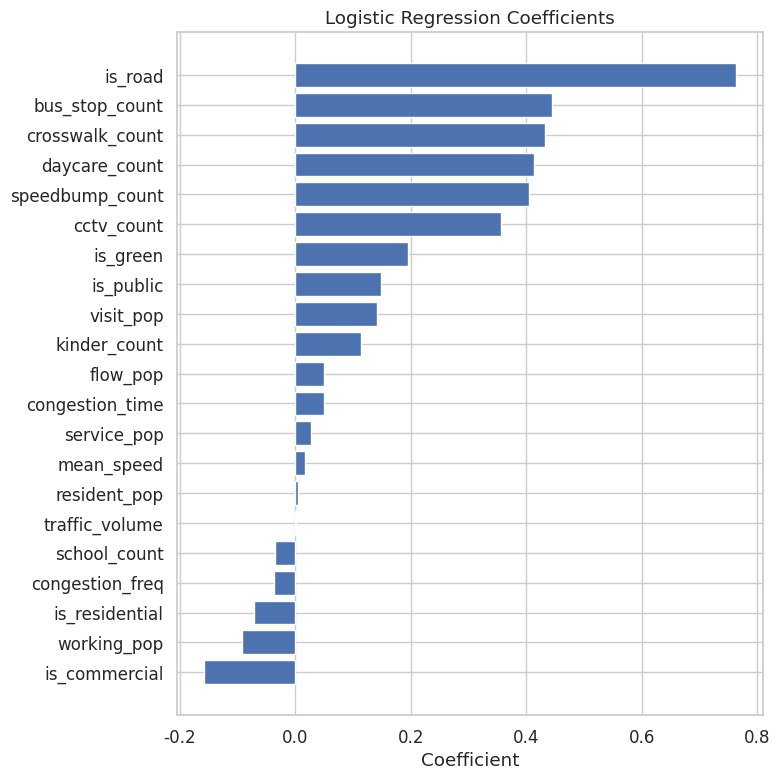

In [26]:
plt.figure(figsize=(8, 8))
coef_plot = logit_coef.sort_values("coef")
plt.barh(coef_plot["feature"], coef_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

## 사고 발생 확률 모형

Logistic Regression을 이용하여 격자별 사고 발생 여부(`acc_binary`)를 예측하였다.

이 모형의 산출값 `risk_prob`는 해당 격자에서 사고가 발생할 가능성을 의미한다.

## 사고 강도 모형 (Conditional Negative Binomial)

사고 강도 모형은 사고가 실제로 발생한 격자(`acc_cnt > 0`)만을 대상으로 적합하였다.

이를 통해 `risk_intensity`는 전체 격자 기준 기대 사고건수가 아니라,
사고가 발생한 경우의 조건부 기대 사고건수
`E(acc_cnt | acc_cnt > 0, X)`로 해석할 수 있다.

최종적으로 위험지표는 다음과 같이 정의하였다.

`risk_score = risk_prob × risk_intensity`

여기서

- `risk_prob = P(acc_cnt > 0 | X)`
- `risk_intensity = E(acc_cnt | acc_cnt > 0, X)`

이다.

In [27]:
## NB용 데이터 만들기 (modeling1이랑 다른 코드)
# Conditional NB: acc_cnt > 0 인 격자만 사용

nb_df = model_df[model_df["acc_cnt"] > 0].copy()

print("NB training rows:", nb_df.shape[0])
print(nb_df["acc_cnt"].describe())

NB training rows: 7308
count    7308.000000
mean        1.951697
std         1.876360
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        24.000000
Name: acc_cnt, dtype: float64


In [28]:
# train/test split for NB

In [29]:
X_nb = nb_df[feature_cols].copy()
y_nb = nb_df["acc_cnt"].copy()

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.2,
    random_state=42
)

print(X_train_nb.shape, X_test_nb.shape)

(5846, 21) (1462, 21)


In [30]:
# statsmodels GLM NB
X_train_nb_sm = sm.add_constant(X_train_nb, has_constant="add")
X_test_nb_sm = sm.add_constant(X_test_nb, has_constant="add")

nb_model_eval = sm.GLM(
    y_train_nb,
    X_train_nb_sm,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_eval.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:                 5846
Model:                            GLM   Df Residuals:                     5825
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10758.
Date:                Fri, 13 Mar 2026   Deviance:                       1357.6
Time:                        08:13:16   Pearson chi2:                 2.03e+03
No. Iterations:                     9   Pseudo R-squ. (CS):            0.09319
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2573      0.058     

In [31]:
y_nb_pred = nb_model_eval.predict(X_test_nb_sm)

print("=== Conditional NB Evaluation (positive grids only) ===")
print("MAE:", mean_absolute_error(y_test_nb, y_nb_pred))
print("Correlation:", np.corrcoef(y_test_nb, y_nb_pred)[0, 1])

eval_nb_df = pd.DataFrame({
    "actual_acc_cnt": y_test_nb.values,
    "pred_acc_cnt": y_nb_pred
})

display(eval_nb_df.head())

=== Conditional NB Evaluation (positive grids only) ===
MAE: 1.0289103214892117
Correlation: 0.3909232550516003


,actual_acc_cnt,pred_acc_cnt
99112,1,1.267004
104777,5,2.658582
103423,2,2.365182
14626,1,1.477190
82668,1,1.113562


In [32]:
X_nb_full = sm.add_constant(X_nb, has_constant="add")

nb_model = sm.GLM(
    y_nb,
    X_nb_full,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:                 7308
Model:                            GLM   Df Residuals:                     7287
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13460.
Date:                Fri, 13 Mar 2026   Deviance:                       1697.6
Time:                        08:13:32   Pearson chi2:                 2.57e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.09143
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2615      0.052     

In [33]:
X_all_nb = sm.add_constant(model_df[feature_cols], has_constant="add")
model_df["risk_intensity"] = nb_model.predict(X_all_nb)

In [34]:
# 최종 risk_score 계산
model_df["risk_score"] = model_df["risk_prob"] * model_df["risk_intensity"]

display(
    model_df[[
        "gid", "acc_cnt", "acc_binary",
        "risk_prob", "risk_intensity", "risk_score"
    ]].head()
)

,gid,acc_cnt,acc_binary,risk_prob,risk_intensity,risk_score
0,다사581304,0,0,0.074775,1.298818,0.097119
1,다사581305,0,0,0.074941,1.299298,0.097370
2,다사581306,0,0,0.074775,1.298818,0.097119
3,다사582304,0,0,0.074780,1.299010,0.097140
4,다사582305,0,0,0.074927,1.299279,0.097351


In [35]:
# risk decil validation

model_df["risk_decile"] = pd.qcut(
    model_df["risk_score"],
    q=10,
    labels=False,
    duplicates="drop"
)

risk_decile_summary = (
    model_df.groupby("risk_decile", as_index=False)
    .agg(
        mean_risk_score=("risk_score", "mean"),
        mean_acc_cnt=("acc_cnt", "mean"),
        accident_rate=("acc_binary", "mean"),
        grid_count=("gid", "count")
    )
)

display(risk_decile_summary)

,risk_decile,mean_risk_score,mean_acc_cnt,accident_rate,grid_count
0,0,0.097004,0.000660,0.000660,27290
1,1,0.097194,0.000711,0.000711,4220
2,2,0.097614,0.000666,0.000666,10503
3,3,0.098696,0.001904,0.001904,10503
4,4,0.101042,0.003904,0.003523,10503
5,5,0.151575,0.026754,0.023517,10503
6,6,0.479551,0.070551,0.061316,10503
7,7,0.891212,0.227840,0.161573,10503
8,8,1.923288,1.024276,0.441260,10504


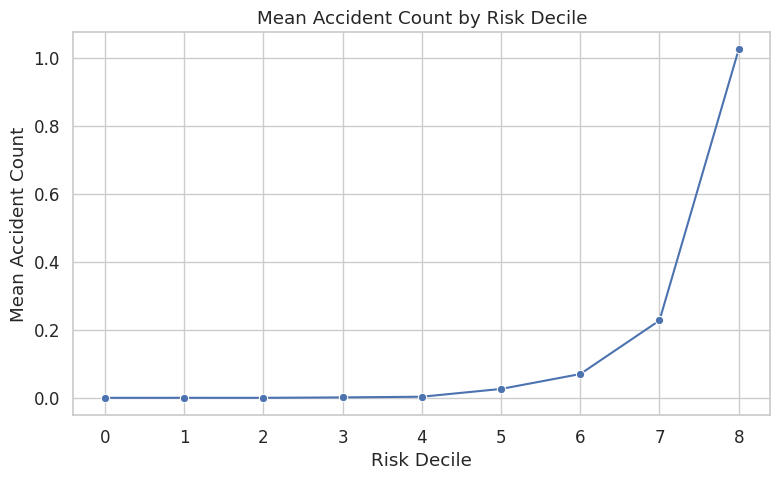

In [36]:
plt.figure(figsize=(8,5))
sns.lineplot(data=risk_decile_summary, x="risk_decile", y="mean_acc_cnt", marker="o")
plt.title("Mean Accident Count by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Mean Accident Count")
plt.tight_layout()
plt.show()

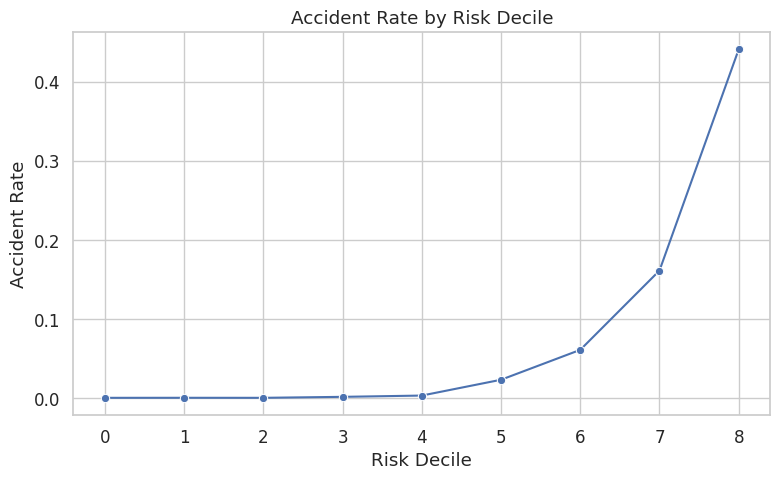

In [37]:
plt.figure(figsize=(8,5))
sns.lineplot(data=risk_decile_summary, x="risk_decile", y="accident_rate", marker="o")
plt.title("Accident Rate by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Accident Rate")
plt.tight_layout()
plt.show()

In [38]:
for p in [0.90, 0.95]:
    threshold = model_df["risk_score"].quantile(p)
    high_risk = model_df[model_df["risk_score"] >= threshold]

    acc_share = high_risk["acc_cnt"].sum() / model_df["acc_cnt"].sum()

    print(f"=== Top {int((1-p)*100)}% high-risk grids ===")
    print("grid count:", len(high_risk))
    print("accident share captured:", round(acc_share, 4))
    print("mean acc_cnt:", round(high_risk["acc_cnt"].mean(), 4))
    print("accident rate:", round(high_risk["acc_binary"].mean(), 4))
    print()

=== Top 9% high-risk grids ===
grid count: 10504
accident share captured: 0.7543
mean acc_cnt: 1.0243
accident rate: 0.4413

=== Top 5% high-risk grids ===
grid count: 5252
accident share captured: 0.5619
mean acc_cnt: 1.5261
accident rate: 0.5685



In [39]:
X_gyosan = pred_base_final[feature_cols].copy()

# 1단계: 사고 발생 확률
pred_base_final["risk_prob"] = logit_model.predict_proba(X_gyosan)[:, 1]

# 2단계: 사고 발생 시 조건부 기대 사고건수
X_gyosan_nb = sm.add_constant(X_gyosan, has_constant="add")
pred_base_final["risk_intensity"] = nb_model.predict(X_gyosan_nb)

# 최종 점수
pred_base_final["risk_score"] = (
    pred_base_final["risk_prob"] * pred_base_final["risk_intensity"]
)

display(
    pred_base_final[[
        "gid", "city", "blockType_main",
        "risk_prob", "risk_intensity", "risk_score"
    ]].head()
)

,gid,city,blockType_main,risk_prob,risk_intensity,risk_score
0,다사720443,경기도 하남시,unknown,0.191250,1.294472,0.247567
1,다사720444,경기도 하남시,단독주택,0.685228,1.591526,1.090558
2,다사721443,경기도 하남시,unknown,0.191250,1.294472,0.247567
3,다사721444,경기도 하남시,단독주택,0.685228,1.591526,1.090558
4,다사721445,경기도 하남시,unknown,0.316045,1.189152,0.375826


In [40]:
pred_final = pred_base_final.copy()

pred_final["risk_rank_pct"] = pred_final["risk_score"].rank(pct=True)

pred_final["risk_grade"] = pd.cut(
    pred_final["risk_rank_pct"],
    bins=[0, 0.5, 0.8, 0.95, 1.0],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

display(
    pred_final[[
        "gid", "city", "blockType_main",
        "risk_prob", "risk_intensity", "risk_score",
        "risk_rank_pct", "risk_grade"
    ]].head()
)

print(pred_final["risk_score"].describe())
print(pred_final["risk_grade"].value_counts())

,gid,city,blockType_main,risk_prob,risk_intensity,risk_score,risk_rank_pct,risk_grade
0,다사720443,경기도 하남시,unknown,0.191250,1.294472,0.247567,0.136364,Low
1,다사720444,경기도 하남시,단독주택,0.685228,1.591526,1.090558,0.694156,Medium
2,다사721443,경기도 하남시,unknown,0.191250,1.294472,0.247567,0.136364,Low
3,다사721444,경기도 하남시,단독주택,0.685228,1.591526,1.090558,0.694156,Medium
4,다사721445,경기도 하남시,unknown,0.316045,1.189152,0.375826,0.279870,Low


count    770.000000
mean       0.881700
std        0.616912
min        0.097119
25%        0.374778
50%        0.685279
75%        1.433561
max        1.988850
Name: risk_score, dtype: float64
risk_grade
Low          342
Medium       273
High         114
Very High     41
Name: count, dtype: int64


In [41]:
csv_fp = os.path.join(DATA_DIR, "02_gyosan_risk_score_final_v2.csv")
pred_final.to_csv(csv_fp, index=False, encoding="utf-8-sig")
print("CSV saved:", csv_fp)

CSV saved: ../outputs/processed/02_gyosan_risk_score_final_v2.csv


In [42]:
pred_geo = pred_final.copy()
pred_geo = gpd.GeoDataFrame(pred_geo, geometry="geometry", crs="EPSG:4326")
pred_geo["risk_grade"] = pred_geo["risk_grade"].astype(str)

geojson_fp = os.path.join(DATA_DIR, "02_gyosan_risk_score_final_v2.geojson")
pred_geo.to_file(geojson_fp, driver="GeoJSON")

print("GeoJSON saved:", geojson_fp)

GeoJSON saved: ../outputs/processed/02_gyosan_risk_score_final_v2.geojson


In [43]:
print("MAE:", mean_absolute_error(y_test_nb, y_nb_pred))
print("Correlation:", np.corrcoef(y_test_nb, y_nb_pred)[0, 1])

MAE: 1.0289103214892117
Correlation: 0.3909232550516003


In [44]:
risk_decile_summary

,risk_decile,mean_risk_score,mean_acc_cnt,accident_rate,grid_count
0,0,0.097004,0.000660,0.000660,27290
1,1,0.097194,0.000711,0.000711,4220
2,2,0.097614,0.000666,0.000666,10503
3,3,0.098696,0.001904,0.001904,10503
4,4,0.101042,0.003904,0.003523,10503
5,5,0.151575,0.026754,0.023517,10503
6,6,0.479551,0.070551,0.061316,10503
7,7,0.891212,0.227840,0.161573,10503
8,8,1.923288,1.024276,0.441260,10504


In [45]:
print(pred_final["risk_grade"].value_counts())

risk_grade
Low          342
Medium       273
High         114
Very High     41
Name: count, dtype: int64


In [46]:
for p in [0.90, 0.95]:
    threshold = model_df["risk_score"].quantile(p)
    high_risk = model_df[model_df["risk_score"] >= threshold]

    acc_share = high_risk["acc_cnt"].sum() / model_df["acc_cnt"].sum()

    print(f"=== Top {int((1-p)*100)}% high-risk grids ===")
    print("grid count:", len(high_risk))
    print("accident share captured:", round(acc_share,4))

=== Top 9% high-risk grids ===
grid count: 10504
accident share captured: 0.7543
=== Top 5% high-risk grids ===
grid count: 5252
accident share captured: 0.5619


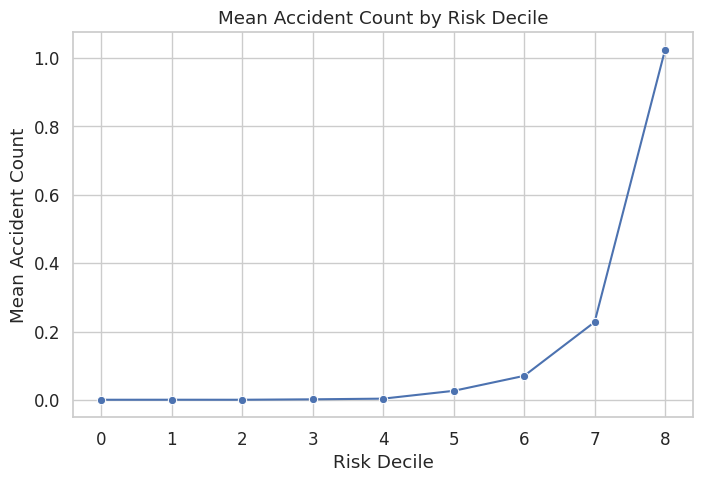

In [47]:
plt.figure(figsize=(8,5))
sns.lineplot(data=risk_decile_summary,
             x="risk_decile",
             y="mean_acc_cnt",
             marker="o")

plt.title("Mean Accident Count by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Mean Accident Count")
plt.show()

In [48]:
model_df["risk_score"].describe()

count    105032.000000
mean          0.403418
std           0.654477
min           0.069293
25%           0.097119
50%           0.099500
75%           0.479053
max          34.001333
Name: risk_score, dtype: float64

In [50]:
train_gdf["blockType_main"].value_counts()

blockType_main
unknown            93888
도로                  2133
아파트                 2037
공동주택                1370
공원                   977
                   ...  
지원시설                   1
저수지                    1
전용관로상의수도시설및송수시설        1
액화석유가스충전소              1
기숙사                    1
Name: count, Length: 79, dtype: int64

In [51]:
train_gdf["landuse_group"].value_counts(normalize=True)

landuse_group
other          0.951367
road           0.021774
green          0.018109
public         0.005341
commercial     0.002514
residential    0.000895
Name: proportion, dtype: float64

In [52]:
print(grid4_block.crs)
print(train_gdf.crs)

EPSG:4326
EPSG:4326


In [53]:
feature_cols = [
    "resident_pop",
    "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count"
]

In [54]:
required_train_cols = ["gid", "city", "geometry", "acc_cnt", "acc_binary"] + feature_cols
required_pred_cols = ["gid", "city", "geometry"] + feature_cols

In [55]:
model_df = train_base_final.copy()

X = model_df[feature_cols].copy()
y_bin = model_df["acc_binary"].copy()
y_cnt = model_df["acc_cnt"].copy()

print("X shape:", X.shape)
print("acc_binary mean:", y_bin.mean())
print("acc_cnt mean:", y_cnt.mean())
display(X.head())

X shape: (105032, 16)
acc_binary mean: 0.06957879503389443
acc_cnt mean: 0.135796709574225


,resident_pop,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.031594,0.015572,0.016022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.022768,0.018269,0.004499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.031655,0.016485,0.015169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

logit_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

logit_model.fit(X_train, y_train)

y_prob = logit_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("=== Logistic Regression Evaluation ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

=== Logistic Regression Evaluation ===
ROC-AUC: 0.9271900860863719
Precision: 0.28638288388678407
Recall: 0.8789329685362517
F1: 0.4320053790553034

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     19545
           1       0.29      0.88      0.43      1462

    accuracy                           0.84     21007
   macro avg       0.64      0.86      0.67     21007
weighted avg       0.94      0.84      0.87     21007


Confusion Matrix
[[16343  3202]
 [  177  1285]]


In [57]:
logit_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef": logit_model.coef_[0]
}).sort_values("coef", ascending=False)

display(logit_coef)

,feature,coef
9,crosswalk_count,0.463287
10,bus_stop_count,0.462372
14,cctv_count,0.403404
15,speedbump_count,0.385125
13,daycare_count,0.326545
3,visit_pop,0.143742
8,congestion_time,0.052117
1,flow_pop,0.050943
12,kinder_count,0.039902
5,mean_speed,0.015998


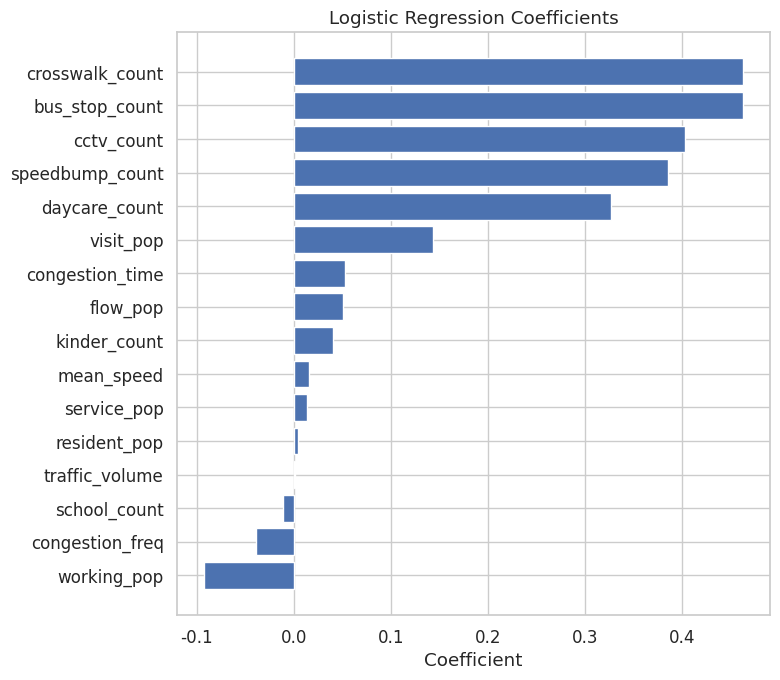

In [58]:
plt.figure(figsize=(8, 7))
coef_plot = logit_coef.sort_values("coef")

plt.barh(coef_plot["feature"], coef_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

## 사고 발생 확률 모형

Logistic Regression을 이용하여 격자별 사고 발생 여부(`acc_binary`)를 예측하였다.

이 모형의 산출값 `risk_prob`는 해당 격자에서 사고가 발생할 가능성
`P(acc_cnt > 0 | X)`를 의미한다.

In [59]:
model_df["risk_prob"] = logit_model.predict_proba(X)[:, 1]

display(
    model_df[["gid", "acc_binary", "risk_prob"]].head()
)

,gid,acc_binary,risk_prob
0,다사581304,0,0.075353
1,다사581305,0,0.075525
2,다사581306,0,0.075353
3,다사582304,0,0.075361
4,다사582305,0,0.075511


In [60]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

nb_df = model_df[model_df["acc_cnt"] > 0].copy()

print("NB training rows:", nb_df.shape[0])
print(nb_df["acc_cnt"].describe())

NB training rows: 7308
count    7308.000000
mean        1.951697
std         1.876360
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        24.000000
Name: acc_cnt, dtype: float64


In [61]:
X_nb = nb_df[feature_cols].copy()
y_nb = nb_df["acc_cnt"].copy()

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.2,
    random_state=42
)

print(X_train_nb.shape, X_test_nb.shape)

(5846, 16) (1462, 16)


In [62]:
X_train_nb_sm = sm.add_constant(X_train_nb, has_constant="add")
X_test_nb_sm = sm.add_constant(X_test_nb, has_constant="add")

nb_model_eval = sm.GLM(
    y_train_nb,
    X_train_nb_sm,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_eval.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:                 5846
Model:                            GLM   Df Residuals:                     5830
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10766.
Date:                Fri, 13 Mar 2026   Deviance:                       1374.2
Time:                        10:43:07   Pearson chi2:                 2.08e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.09061
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2536      0.058     

In [63]:
y_nb_pred = nb_model_eval.predict(X_test_nb_sm)

print("=== Conditional NB Evaluation (positive grids only) ===")
print("MAE:", mean_absolute_error(y_test_nb, y_nb_pred))
print("Correlation:", np.corrcoef(y_test_nb, y_nb_pred)[0, 1])

eval_nb_df = pd.DataFrame({
    "actual_acc_cnt": y_test_nb.values,
    "pred_acc_cnt": y_nb_pred
})

display(eval_nb_df.head())

=== Conditional NB Evaluation (positive grids only) ===
MAE: 1.028654728261787
Correlation: 0.3847445390440844


,actual_acc_cnt,pred_acc_cnt
99112,1,1.299294
104777,5,2.751708
103423,2,2.433442
14626,1,1.498928
82668,1,1.104741


In [64]:
X_nb_full = sm.add_constant(X_nb, has_constant="add")

nb_model = sm.GLM(
    y_nb,
    X_nb_full,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:                 7308
Model:                            GLM   Df Residuals:                     7292
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13471.
Date:                Fri, 13 Mar 2026   Deviance:                       1719.9
Time:                        10:43:19   Pearson chi2:                 2.64e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.08865
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2584      0.051     

In [65]:
X_all_nb = sm.add_constant(model_df[feature_cols], has_constant="add")
model_df["risk_intensity"] = nb_model.predict(X_all_nb)

display(
    model_df[["gid", "acc_cnt", "risk_intensity"]].head()
)

,gid,acc_cnt,risk_intensity
0,다사581304,0,1.294883
1,다사581305,0,1.297394
2,다사581306,0,1.294883
3,다사582304,0,1.296546
4,다사582305,0,1.297380


In [66]:
model_df["risk_score"] = model_df["risk_prob"] * model_df["risk_intensity"]

display(
    model_df[[
        "gid", "acc_cnt", "acc_binary",
        "risk_prob", "risk_intensity", "risk_score"
    ]].head()
)

,gid,acc_cnt,acc_binary,risk_prob,risk_intensity,risk_score
0,다사581304,0,0,0.075353,1.294883,0.097574
1,다사581305,0,0,0.075525,1.297394,0.097986
2,다사581306,0,0,0.075353,1.294883,0.097574
3,다사582304,0,0,0.075361,1.296546,0.097709
4,다사582305,0,0,0.075511,1.297380,0.097967


In [67]:
model_df["risk_decile"] = pd.qcut(
    model_df["risk_score"],
    q=10,
    labels=False,
    duplicates="drop"
)

risk_decile_summary = (
    model_df.groupby("risk_decile", as_index=False)
    .agg(
        mean_risk_score=("risk_score", "mean"),
        mean_acc_cnt=("acc_cnt", "mean"),
        accident_rate=("acc_binary", "mean"),
        grid_count=("gid", "count")
    )
)

display(risk_decile_summary)

,risk_decile,mean_risk_score,mean_acc_cnt,accident_rate,grid_count
0,0,0.097462,0.000696,0.000696,22987
1,1,0.097702,0.000469,0.000469,8523
2,2,0.098215,0.000762,0.000762,10503
3,3,0.099279,0.001904,0.001904,10503
4,4,0.101625,0.004284,0.003808,10503
5,5,0.152479,0.026088,0.023231,10503
6,6,0.484471,0.072836,0.062649,10503
7,7,0.903803,0.230125,0.163477,10503
8,8,1.922068,1.019992,0.438024,10504


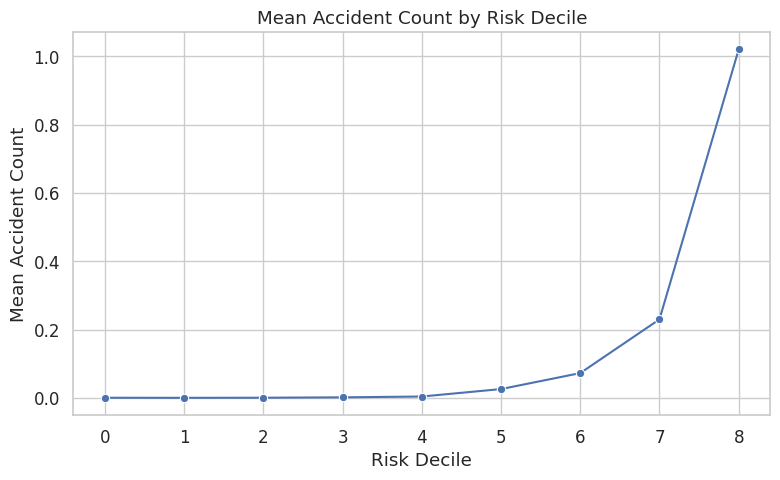

In [68]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=risk_decile_summary, x="risk_decile", y="mean_acc_cnt", marker="o")
plt.title("Mean Accident Count by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Mean Accident Count")
plt.tight_layout()
plt.show()

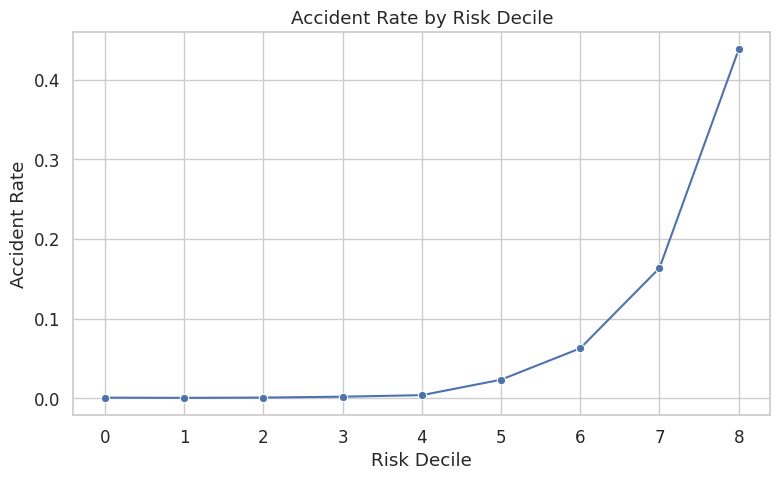

In [69]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=risk_decile_summary, x="risk_decile", y="accident_rate", marker="o")
plt.title("Accident Rate by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Accident Rate")
plt.tight_layout()
plt.show()

In [70]:
for p in [0.90, 0.95]:
    threshold = model_df["risk_score"].quantile(p)
    high_risk = model_df[model_df["risk_score"] >= threshold]

    acc_share = high_risk["acc_cnt"].sum() / model_df["acc_cnt"].sum()

    print(f"=== Top {int((1-p)*100)}% high-risk grids ===")
    print("grid count:", len(high_risk))
    print("accident share captured:", round(acc_share, 4))
    print("mean acc_cnt:", round(high_risk["acc_cnt"].mean(), 4))
    print("accident rate:", round(high_risk["acc_binary"].mean(), 4))
    print()

=== Top 9% high-risk grids ===
grid count: 10504
accident share captured: 0.7512
mean acc_cnt: 1.02
accident rate: 0.438

=== Top 5% high-risk grids ===
grid count: 5252
accident share captured: 0.5637
mean acc_cnt: 1.5308
accident rate: 0.5699



In [71]:
y_train_prob = logit_model.predict_proba(X_train)[:,1]

print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Train ROC-AUC: 0.9300440959772409
Test ROC-AUC: 0.9271900860863719


In [72]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": nb_model.params[1:]
}).sort_values("coef", ascending=False)

coef_df

,feature,coef
crosswalk_count,crosswalk_count,0.116234
cctv_count,cctv_count,0.068178
flow_pop,flow_pop,0.040792
bus_stop_count,bus_stop_count,0.028603
visit_pop,visit_pop,0.028398
speedbump_count,speedbump_count,0.027436
congestion_time,congestion_time,0.012805
working_pop,working_pop,0.012394
traffic_volume,traffic_volume,0.000309
resident_pop,resident_pop,-0.000397


In [73]:
# 고위험 격자 이유 확인하기
# 최종 결과 불러오기
pred_final = pd.read_csv("../outputs/processed/02_gyosan_risk_score_final_v2.csv")

# feature 목록
feature_cols = [
    "resident_pop",
    "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count"
]

# Very High만 추출
vh = pred_final[pred_final["risk_grade"] == "Very High"].copy()

print(vh.shape)
vh.head()

(41, 31)


,gid,city,geometry,resident_pop,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,...,is_green,is_road,is_public,blockType_main,landuse_group,risk_prob,risk_intensity,risk_score,risk_rank_pct,risk_grade
29,다사723450,경기도 하남시,"POLYGON ((127.1866006961166 37.50385384300978,...",0.000000,11.148592,3.200979,7.947613,0.926026,29.441706,464.470709,...,0,1,0,도로,road,0.951171,2.088946,1.986944,0.982468,Very High
42,다사724448,경기도 하남시,"POLYGON ((127.1877395940134 37.50205413364287,...",0.000000,11.148592,3.200979,7.947613,0.926026,29.441706,464.470709,...,0,1,0,도로,road,0.951171,2.088946,1.986944,0.982468,Very High
67,다사725449,경기도 하남시,"POLYGON ((127.18886721674042 37.502958471807, ...",0.000000,11.148592,3.200979,7.947613,0.926026,29.441706,464.470709,...,0,1,0,도로,road,0.951171,2.088946,1.986944,0.982468,Very High
114,다사727442,경기도 하남시,POLYGON ((127.19115595832318 37.49665493489996...,17.913374,11.148592,3.200979,7.947613,0.926026,29.441706,464.470709,...,0,1,0,도로,road,0.954322,2.070499,1.975922,0.963636,Very High
173,다사728470,경기도 하남시,POLYGON ((127.19218362084565 37.52189574904486...,0.000000,11.148592,3.200979,7.947613,0.926026,29.441706,464.470709,...,0,1,0,도로,road,0.951171,2.088946,1.986944,0.982468,Very High


In [74]:
overall_mean = pred_final[feature_cols].mean()
overall_std = pred_final[feature_cols].std().replace(0, np.nan)

In [75]:
# logistic 계수
logit_coef_map = dict(zip(logit_coef["feature"], logit_coef["coef"]))

# NB 계수
nb_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": nb_model.params[1:]   # const 제외
})
nb_coef_map = dict(zip(nb_coef_df["feature"], nb_coef_df["coef"]))

In [76]:
# 격자별 설명용 contribution 계산
def explain_one_grid(row, top_n=5):
    rows = []
    for f in feature_cols:
        z = (row[f] - overall_mean[f]) / overall_std[f] if pd.notnull(overall_std[f]) else 0
        
        logit_contrib = z * logit_coef_map.get(f, 0)
        nb_contrib = z * nb_coef_map.get(f, 0)
        total_contrib = logit_contrib + nb_contrib
        
        rows.append({
            "feature": f,
            "value": row[f],
            "zscore_vs_all": z,
            "logit_coef": logit_coef_map.get(f, 0),
            "nb_coef": nb_coef_map.get(f, 0),
            "total_contrib": total_contrib
        })
    
    contrib_df = pd.DataFrame(rows).sort_values("total_contrib", ascending=False)
    return contrib_df.head(top_n)

In [77]:
sample_gid = vh.iloc[0]["gid"]
sample_row = vh[vh["gid"] == sample_gid].iloc[0]

explain_df = explain_one_grid(sample_row, top_n=7)
explain_df

,feature,value,zscore_vs_all,logit_coef,nb_coef,total_contrib
9,crosswalk_count,1.183310,1.567348,0.463287,0.116234,0.908311
10,bus_stop_count,0.512424,1.682631,0.462372,0.028603,0.826130
14,cctv_count,0.180497,0.933862,0.403404,0.068178,0.440392
3,visit_pop,7.947613,0.761592,0.143742,0.028398,0.131100
8,congestion_time,70.853856,1.572314,0.052117,0.012805,0.102078
15,speedbump_count,0.086732,0.238277,0.385125,0.027436,0.098304
13,daycare_count,0.118612,0.246916,0.326545,-0.017476,0.076314


In [78]:
vh_mean = vh[feature_cols].mean()
general_mean = pred_final[feature_cols].mean()

ratio_df = pd.DataFrame({
    "veryhigh_mean": vh_mean,
    "overall_mean": general_mean,
    "ratio": vh_mean / general_mean.replace(0, np.nan)
}).sort_values("ratio", ascending=False)

ratio_df

,veryhigh_mean,overall_mean,ratio
school_count,0.007581,0.002644,2.866834
bus_stop_count,0.536208,0.194439,2.757716
crosswalk_count,1.198758,0.458800,2.612814
cctv_count,0.196082,0.078599,2.494732
working_pop,3.221113,1.758785,1.831442
service_pop,0.932635,0.510766,1.825953
flow_pop,11.226082,6.151337,1.824982
visit_pop,8.004969,4.392552,1.822396
congestion_time,70.404205,39.845974,1.766909
congestion_freq,54.523176,30.997967,1.758927


In [79]:
def make_explanation_text(row, top_n=5):
    top_df = explain_one_grid(row, top_n=top_n)
    reasons = []
    
    for _, r in top_df.iterrows():
        if r["total_contrib"] > 0:
            reasons.append(
                f"{r['feature']}가 전체 평균 대비 높고(표준화 차이 {r['zscore_vs_all']:.2f}), "
                f"모델에서 위험 증가 방향으로 작용"
            )
    
    text = f"격자 {row['gid']}는 " + "; ".join(reasons) + "하여 고위험으로 판정되었다."
    return text

print(make_explanation_text(sample_row, top_n=5))

격자 다사723450는 crosswalk_count가 전체 평균 대비 높고(표준화 차이 1.57), 모델에서 위험 증가 방향으로 작용; bus_stop_count가 전체 평균 대비 높고(표준화 차이 1.68), 모델에서 위험 증가 방향으로 작용; cctv_count가 전체 평균 대비 높고(표준화 차이 0.93), 모델에서 위험 증가 방향으로 작용; visit_pop가 전체 평균 대비 높고(표준화 차이 0.76), 모델에서 위험 증가 방향으로 작용; congestion_time가 전체 평균 대비 높고(표준화 차이 1.57), 모델에서 위험 증가 방향으로 작용하여 고위험으로 판정되었다.


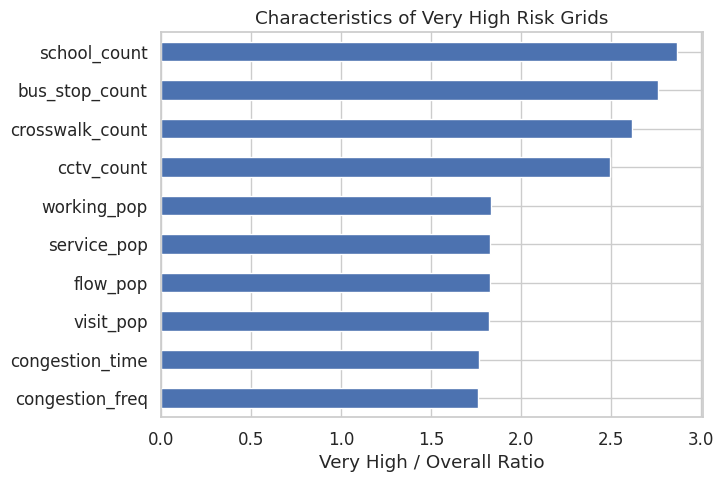

In [80]:
ratio_df.head(10).sort_values("ratio").plot.barh(
    y="ratio", figsize=(7,5), legend=False
)
plt.xlabel("Very High / Overall Ratio")
plt.title("Characteristics of Very High Risk Grids")
plt.show()